<h1> Causal disovery modular experiments batteries

<h2> Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from scipy.io import loadmat
from Preprocessing.imbalanced_performance.preprocess_new import ModularProcesses, CommonProcesses
from project_methods import ProjectMethods
from pathlib import Path
from causal_discovery.algos.notears import NoTears
import networkx as nx
import hashlib
import os
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg

<h2> Dataset

In [2]:
groups = [[1, 4, 6], [2, 7], [3, 8], [5]]
cols = ['Step_Index', 'Ambient_TemperatureC', 'VoltageV', 'CurrentA', 'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4','CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3','CurrentA_Cell_4']
experiment_dataset = ModularProcesses.getExperimentDataSet()
multicausaldataset = CommonProcesses.multienvcausaldiscoverydataset(experiment_dataset, cols, groups)
multicausaldatasetdivided = dict(tuple(multicausaldataset.groupby("Group")))

In [3]:
print(multicausaldataset.head())

   Ambient_TemperatureC  VoltageV  CurrentA  TemperatureC_Cell_1  \
0             19.451006  3.572477       0.0            19.970938   
1             19.451006  3.572603       0.0            19.970938   
2             19.561859  3.572414       0.0            20.016722   
3             19.490467  3.571972       0.0            19.815464   
4             19.492714  3.572288       0.0            19.790602   

   TemperatureC_Cell_2  TemperatureC_Cell_3  TemperatureC_Cell_4  \
0            20.079184            20.310024            20.374929   
1            20.079184            20.310024            20.374929   
2            20.002285            20.341354            20.276442   
3            20.053652            20.234016            20.356627   
4            20.113615            20.214621            20.438178   

   CurrentA_Cell_1  CurrentA_Cell_2  CurrentA_Cell_3  CurrentA_Cell_4  Group  
0         0.345851        -0.278137         0.484834        -0.211766      0  
1         0.342995      

In [4]:
print(multicausaldataset.shape)
print(multicausaldataset.isnull().sum())

(2402969, 12)
Ambient_TemperatureC    0
VoltageV                0
CurrentA                0
TemperatureC_Cell_1     0
TemperatureC_Cell_2     0
TemperatureC_Cell_3     0
TemperatureC_Cell_4     0
CurrentA_Cell_1         0
CurrentA_Cell_2         0
CurrentA_Cell_3         0
CurrentA_Cell_4         0
Group                   0
dtype: int64


<h2> Causal Discovery

In [5]:
labels = [multicausaldataset.columns]
# Convert to numpy array
data = multicausaldataset.to_numpy()
print(data.shape)
print(labels)
n_samples = data.shape[0]
n_features = data.shape[1]
pc_result = pc(data)

(2402969, 12)
[Index(['Ambient_TemperatureC', 'VoltageV', 'CurrentA', 'TemperatureC_Cell_1',
       'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4',
       'CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3',
       'CurrentA_Cell_4', 'Group'],
      dtype='object')]


  0%|          | 0/12 [00:00<?, ?it/s]

In [6]:
pydot_graph_pc = GraphUtils.to_pydot(pc_result.G, labels=labels[0])
pydot_graph_pc.write_png('../Src/structures/3modular_level/images/multienv/pc.png')

<h3> NoTears

<h4> Per group

In [7]:
dags = ProjectMethods.NoTearsByGroup(multicausaldatasetdivided, '../Src/structures/3modular_level/images/multienv/NoTears/ByGroup')
print(dags)

100%|██████████| 20/20 [00:04<00:00,  4.35it/s]

{'52d64dace92498886c69bad58241d1a1': 1, '06d2bb09dc6f6bfdb5c2c4c483614772': 1, '6c5324d409d3da248ce9d6a6815d086c': 1, '8850b1490cbc41345bc19d401732d2f9': 1}


Matrix shape: (11, 11)
Non-zero elements: 46
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.5  0.   0.5  0.5  0.75 0.75 0.75 0.25 0.   0.   0.  ]
 [0.25 0.25 0.   0.25 0.5  0.5  0.5  0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.5  0.75 0.5  0.5  0.5  0.5  0.   0.   0.   0.  ]
 [0.5  0.75 0.75 0.75 0.75 0.75 0.5  0.75 0.   0.   0.  ]
 [0.5  0.5  0.75 0.5  0.5  0.75 0.75 0.25 0.75 0.   0.25]
 [0.25 0.75 0.75 0.5  0.5  0.75 0.75 0.   0.75 0.5  0.  ]]


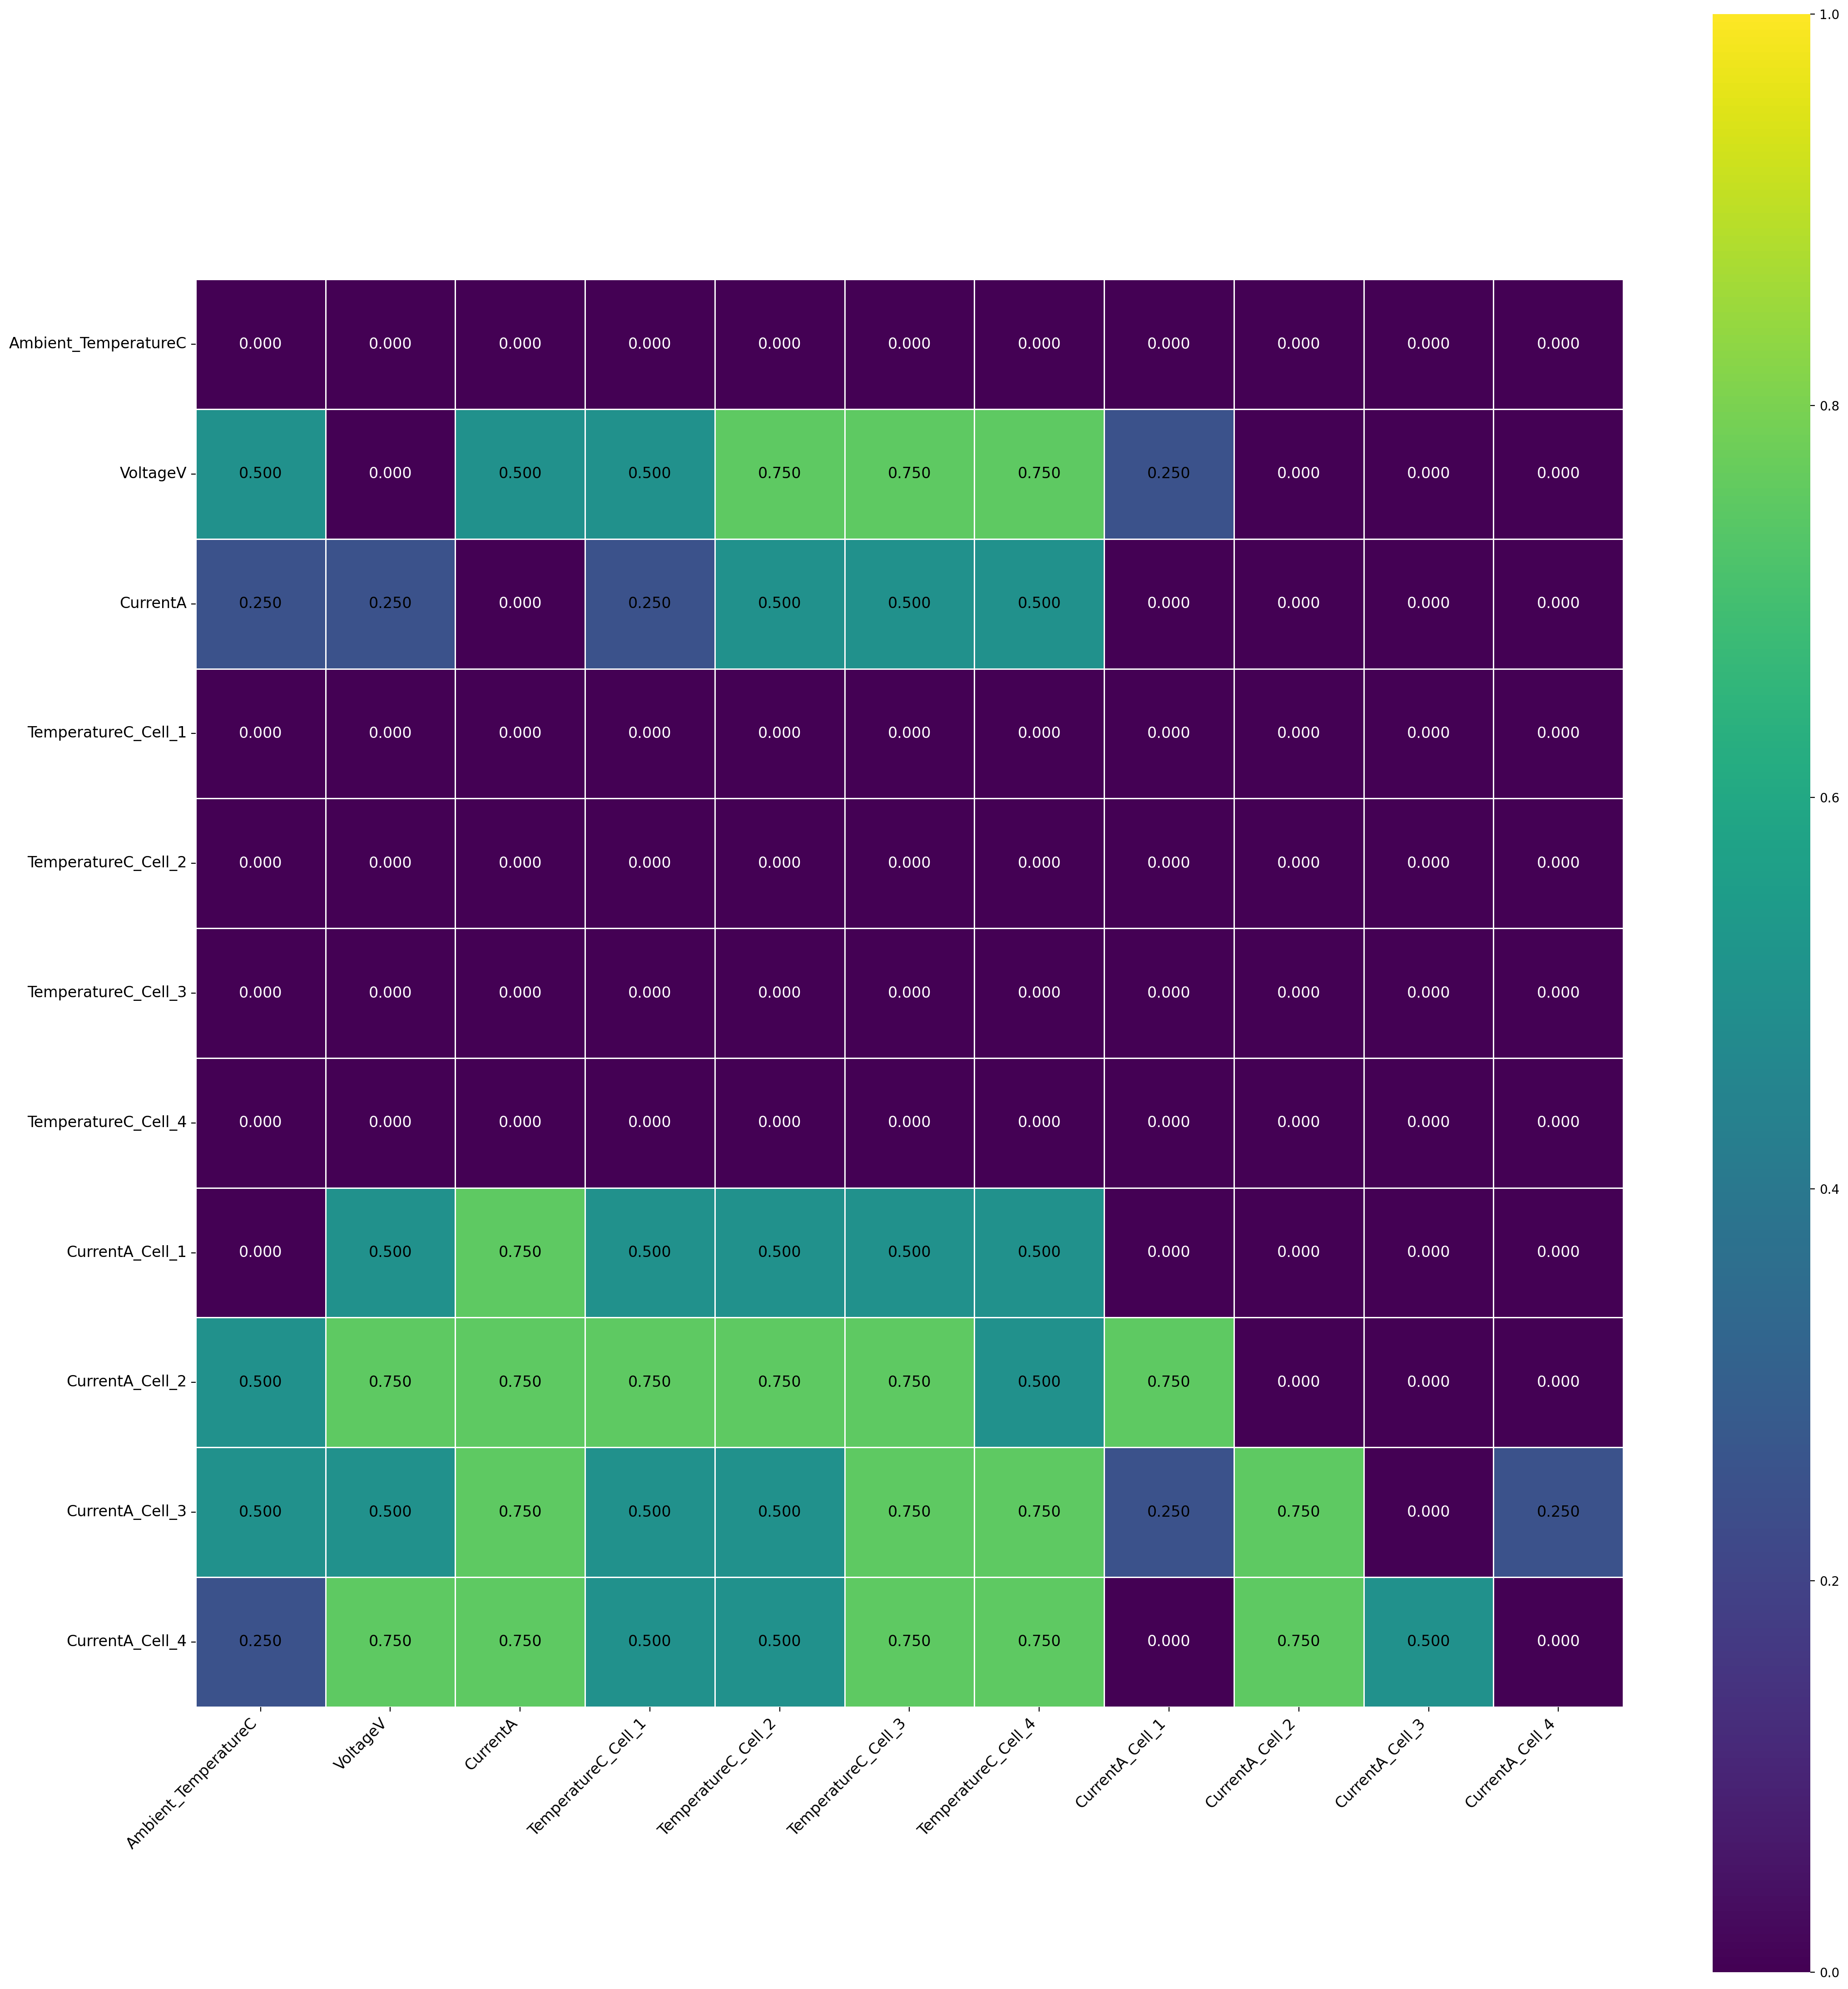

In [8]:
dag_list, cols = ProjectMethods.load_all_dags("../Src/structures/3modular_level/images/multienv/NoTears/ByGroup")           # from saved files
freq_matrix = ProjectMethods.dag_frequency_matrix(dag_list)
print("Matrix shape:", freq_matrix.shape)
print("Non-zero elements:", np.count_nonzero(freq_matrix))
print(freq_matrix)
ProjectMethods.plot_dag_frequency_heatmap(freq_matrix, cols, save_path="../Src/structures/3modular_level/images/multienv/NoTears/ByGroup/edge_frequency_heatmap.png")

In [9]:
dags = ProjectMethods.NoTearsLargeDataset(X_full=data, cols=multicausaldataset.columns.tolist(), save_point='../Src/structures/3modular_level/images/multienv/NoTears/fulldata', subset_size=20000000)
print(dags)

2402969
Running subsample 1/5 (2402969 rows)...


100%|██████████| 20/20 [00:39<00:00,  1.95s/it]


Running subsample 2/5 (2402969 rows)...


100%|██████████| 20/20 [00:40<00:00,  2.03s/it]


Running subsample 3/5 (2402969 rows)...


...

Running subsample 4/5 (2402969 rows)...


100%|██████████| 20/20 [00:54<00:00,  2.74s/it]


Running subsample 5/5 (2402969 rows)...


100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

['Ambient_TemperatureC', 'VoltageV', 'CurrentA', 'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4', 'CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3', 'CurrentA_Cell_4', 'Group']
Saved DAG with threshold 0.3 at ../Src/structures/3modular_level/images/multienv/NoTears/fulldata
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 0 0]
 [1 1 0 1 1 1 1 0 0 0 1 0]]


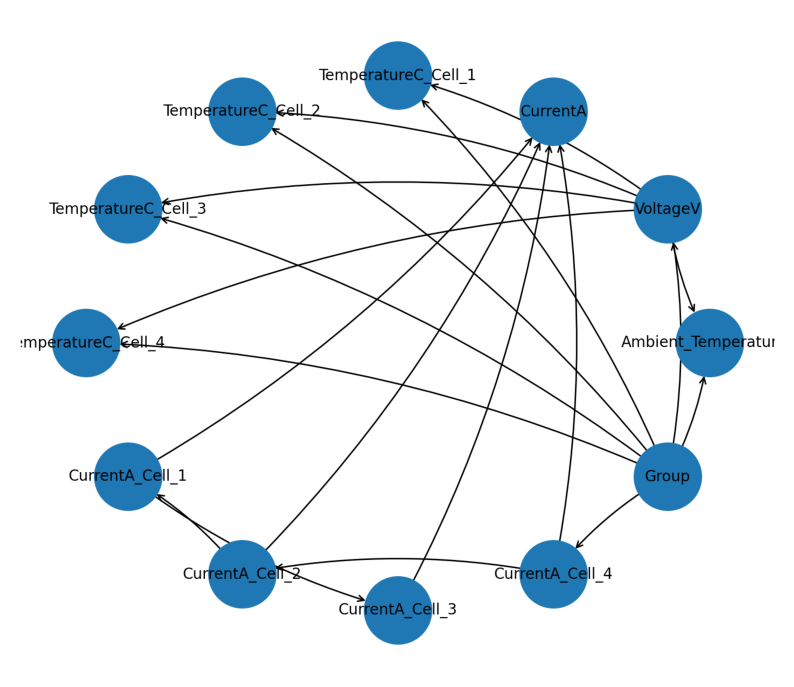

In [10]:
img_path = '../Src/structures/3modular_level/images/multienv/NoTears/fulldata/dag.png'

# Load and show
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()

<h2> Causal Discovery with extra info

In [11]:
groups = [[1, 4, 6], [2, 7], [3, 8], [5]]

cols = ['Type_Cell', 'Age', 'Resistance', 'Temperature', 'Step_Index', 'Ambient_TemperatureC', 'VoltageV', 'CurrentA', 'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4','CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3','CurrentA_Cell_4']
experiment_dataset_extra = ModularProcesses.getExperimentDataSetExtraInfo()
multicausaldataset_extra = CommonProcesses.multienvcausaldiscoverydataset(experiment_dataset_extra, cols, groups)
multicausaldataset_extra['Type_Cell_id'] = multicausaldataset_extra['Type_Cell'].astype('category').cat.codes
multicausaldataset_extra['Age_bin'] = multicausaldataset_extra['Age'].map({'Unaged': 0, 'Aged': 1})
model_features = ['Resistance', 'Temperature', 'Ambient_TemperatureC', 'VoltageV', 
                  'CurrentA', 'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 
                  'TemperatureC_Cell_4','CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3','CurrentA_Cell_4', 'Group', 'Type_Cell_id','Age_bin']
data_extra = multicausaldataset_extra[model_features].values
multicausaldatasetdivided_extra = dict(tuple(multicausaldataset_extra[model_features].groupby("Group")))


<h4> Per group

In [12]:
dags = ProjectMethods.NoTearsByGroup(multicausaldatasetdivided_extra, '../Src/structures/3modular_level/images/multienvExtra/NoTears/ByGroup')
print(dags)

100%|██████████| 20/20 [00:06<00:00,  3.02it/s]

{'7c656fb7b8acbb381fdaaab7b3ae0b11': 1, 'a5726b821938e4634e20cdd7274de3db': 1, '94f66f156b157c0f6f4607cc08dfa859': 1, '7e25e18e9e964771f2d552829ca61482': 1}


Matrix shape: (15, 15)
Non-zero elements: 47
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.75 0.   0.5  0.   0.5  0.5  0.5  0.5  0.5  0.25 0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.75 0.   0.   0.5  0.75 0.   0.25 0.25 0.25 0.   0.   0.   0.25 0.25
  0.  ]
 [0.   0.25 0.25 0.75 0.75 0.   0.   0.   0.25 0.75 0.   0.25 0.   0.
  0.  ]
 [0.25 0.25 0.   0.75 0.75 0.   0.   0.   0.   0.5  0.25 0.   0.5  0.
  0.  ]
 [0.25 0.25 0.   

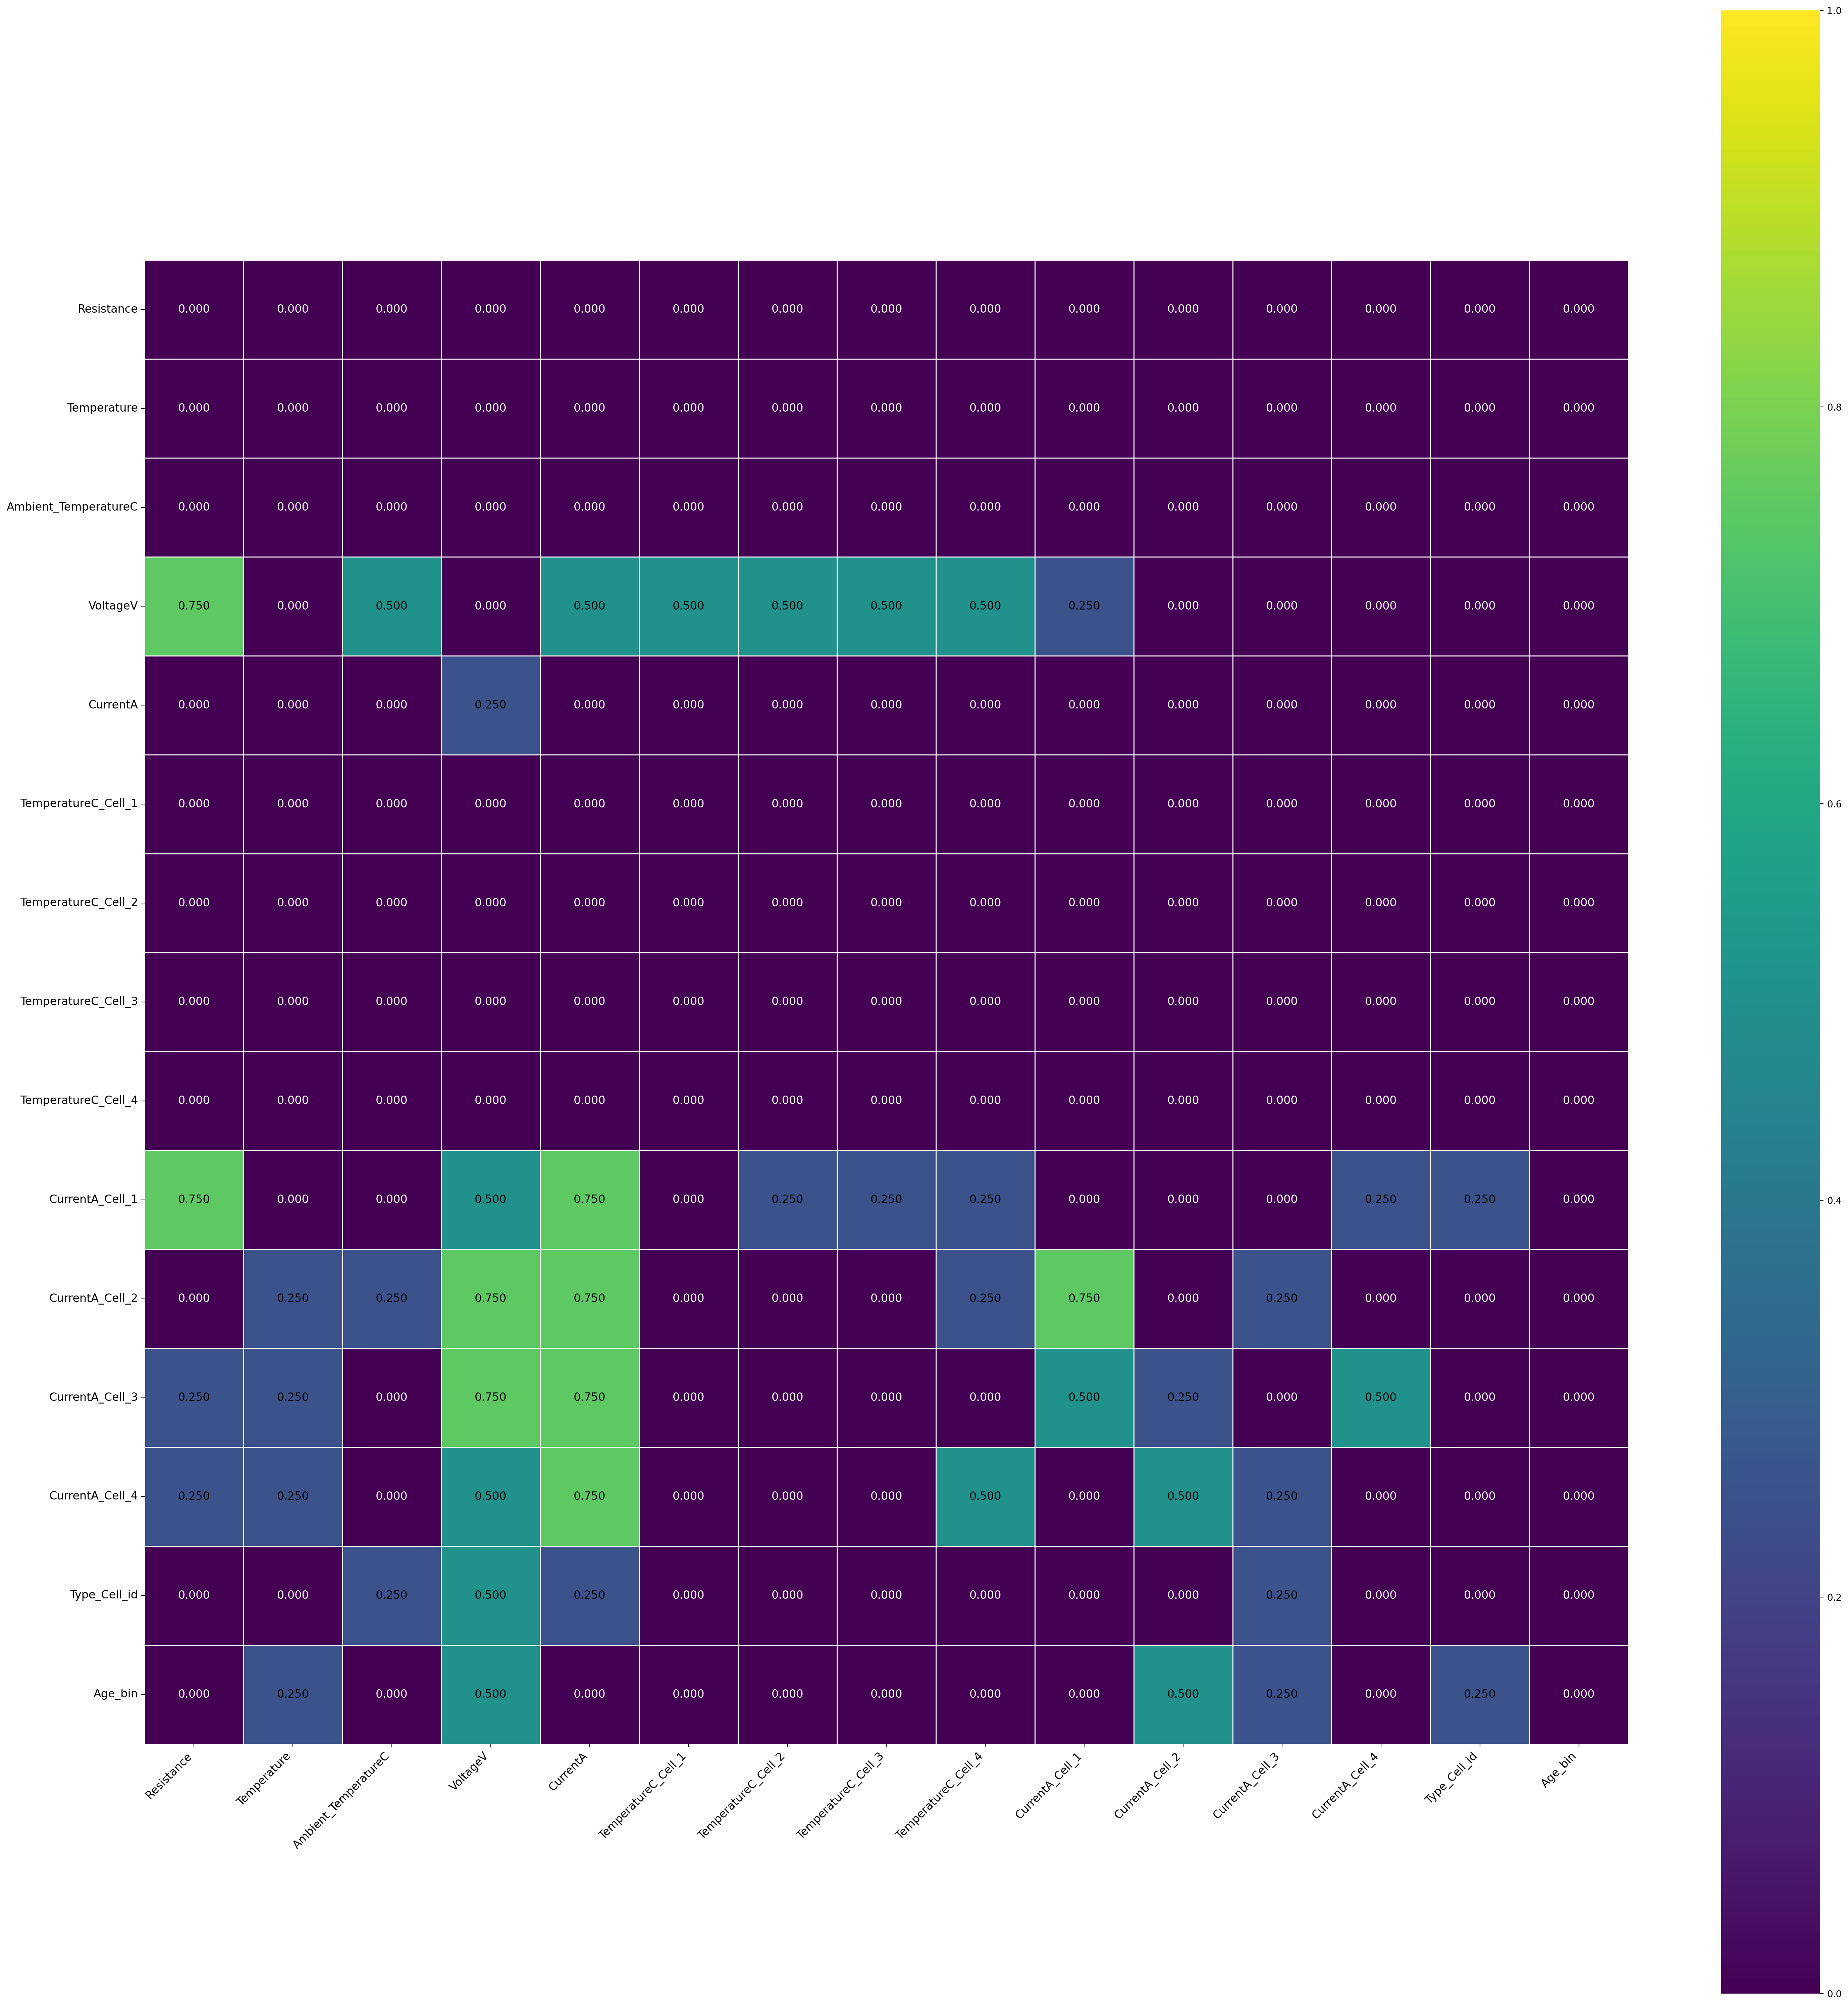

In [13]:
dag_list, cols = ProjectMethods.load_all_dags("../Src/structures/3modular_level/images/multienvExtra/NoTears/ByGroup")           # from saved files
freq_matrix = ProjectMethods.dag_frequency_matrix(dag_list)
print("Matrix shape:", freq_matrix.shape)
print("Non-zero elements:", np.count_nonzero(freq_matrix))
print(freq_matrix)
ProjectMethods.plot_dag_frequency_heatmap(freq_matrix, cols, save_path="../Src/structures/3modular_level/images/multienvExtra/NoTears/ByGroup/edge_frequency_heatmap.png")

In [16]:
dags = ProjectMethods.NoTearsLargeDataset(X_full=data_extra, cols=model_features, save_point='../Src/structures/3modular_level/images/multienvExtra/NoTears/fulldata', subset_size=20000000, n_repeats=10)
print(dags)

2402969
Running subsample 1/10 (2402969 rows)...


100%|██████████| 20/20 [01:03<00:00,  3.16s/it]


Running subsample 2/10 (2402969 rows)...


100%|██████████| 20/20 [01:07<00:00,  3.38s/it]


Running subsample 3/10 (2402969 rows)...


...

Running subsample 9/10 (2402969 rows)...


100%|██████████| 20/20 [01:04<00:00,  3.22s/it]


Running subsample 10/10 (2402969 rows)...


100%|██████████| 20/20 [01:02<00:00,  3.14s/it]

['Resistance', 'Temperature', 'Ambient_TemperatureC', 'VoltageV', 'CurrentA', 'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4', 'CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3', 'CurrentA_Cell_4', 'Group', 'Type_Cell_id', 'Age_bin']
Saved DAG with threshold 0.3 at ../Src/structures/3modular_level/images/multienvExtra/NoTears/fulldata
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0]
 [0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0]]


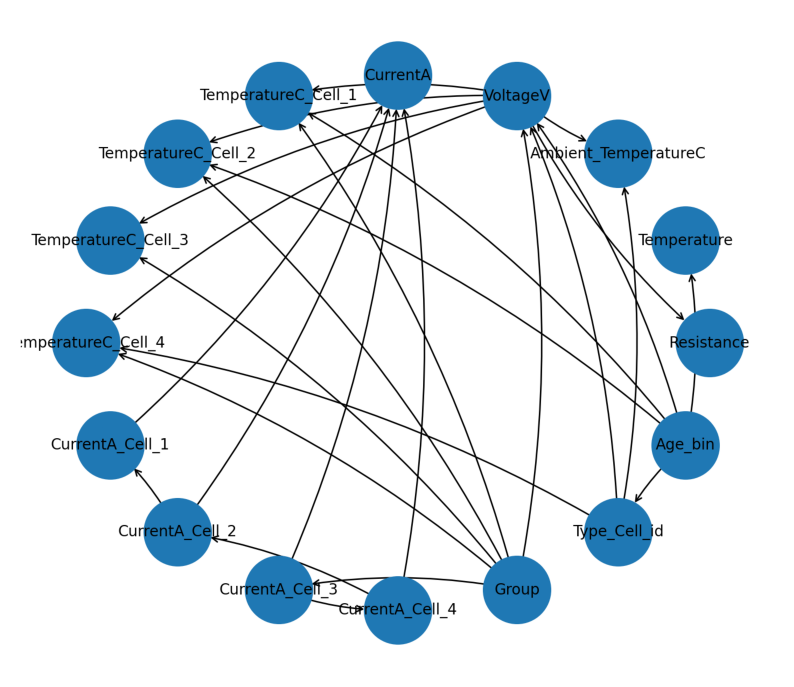

In [17]:
img_path = '../Src/structures/3modular_level/images/multienvExtra/NoTears/fulldata/dag.png'

# Load and show
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()